# Data Discovery using STAC and Xarray

The objective of this notebook is to demonstrate how to integrate data discovery using STAC with data analysis using Xarray.
Xarray is an open source Python library designed for handling multidimensional arrays and datasets, extending the capabilities of NumPy.
STAC, which stands for SpatioTemporal Asset Catalog, is an open standard that facilitates the discovery, search, and use of geospatial data.
It defines a common metadata model and web API that allows users to catalog, search, and access a wide range of spatial datasets such as satellite imagery, aerial photographs, and other geospatial assets.
To understand the structure of such catalogs, you can explore the [EODC Data Catalogue](https://services.eodc.eu/browser/#/?.language=en).
This notebook works with the [AI4SAR_SIG0](https://services.eodc.eu/browser/#/v1/collections/AI4SAR_SIG0) collection provided by the European Open Data Center [EODC](https://eodc.eu/).


### Workflow

1. Getting Started

2. STAC Client

3. STAC Items and Xarray

4. Visualizing the Data

5. Simple Analyses

### 1. Getting Started

We begin by importing the necessary Python packages that allow us to connect to and retrieve data from a STAC API.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pystac
from pystac_client import Client
from odc import stac as odc_stac
from odc.geo.geobox import GeoBox
from affine import Affine
import sys

### 2. STAC Client

The API we use connects to the EODC database through the STAC convention.
If we open the link https://stac.eodc.eu/api/v1in a browser, we can view a JSON file that provides information about the API.
In this JSON file, the key named conformsTo lists the supported functionalities of the API, including how to filter and query catalog items.
The AI4SAR collection used in this notebook contains several items derived from Sentinel 1 data from various timestamps in 2023 near Austria.

The following code demonstrates how to access the AI4SAR collection via the STAC API.

In [ ]:
stac_api = "https://stac.eodc.eu/api/v1"
client = Client.open(stac_api)
collection_id="AI4SAR_SIG0"

Once connected, we can view the metadata of the collection we are working with.

In [ ]:
collection = client.get_collection("AI4SAR_SIG0")
collection

<CollectionClient id=AI4SAR_SIG0>

At this stage we have not yet accessed any actual data from EODC.
We have only loaded metadata into local memory, which takes up negligible space.

In [ ]:
collection_size = sys.getsizeof(collection)
print('Collection size: %.1f KB' % (collection_size / 1024))

Collection size: 0.0 KB


Next, we search for specific items within the AI4SAR_SIG0 collection by defining an area and time period of interest.

In [ ]:
collection_id="AI4SAR_SIG0"

bbox = [15.6, 47.7, 16.6, 48.7]  # [lon_min, lat_min, lon_max, lat_max]
start_date = "2023-01-01"
end_date = "2023-10-31"

query = client.search(bbox=bbox,
                        collections=[collection_id],
                        datetime=f"{start_date}/{end_date}",
                        )
q_items = sorted(query.items(), key=lambda x: x.id)

After executing the search, we can display the list of items found within our query parameters and inspect their count.

In [ ]:
for item in q_items:
    print(item)

print("\n","The length of the list of items is",len(q_items))

<Item id=SIG0_20230418T050210_D124_EU020M_E051N015T3_S1AIWGRDH>
<Item id=SIG0_20230512T050211_D124_EU020M_E051N015T3_S1AIWGRDH>
<Item id=SIG0_20230617T050213_D124_EU020M_E051N015T3_S1AIWGRDH>

 The length of the list of items is 3


We can then explore the metadata of a single item.

In [ ]:
q_items[0].properties

{'gsd': 20,
 'datetime': '2023-04-18T05:02:10Z',
 'proj:bbox': [5100000, 1500000, 5400000, 1800000],
 'proj:wkt2': 'PROJCS["Azimuthal_Equidistant",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433],AUTHORITY["EPSG","4326"]],PROJECTION["Azimuthal_Equidistant"],PARAMETER["latitude_of_center",53],PARAMETER["longitude_of_center",24],PARAMETER["false_easting",5837287.81977],PARAMETER["false_northing",2121415.69617],UNIT["metre",1,AUTHORITY["EPSG","9001"]]]',
 'proj:shape': [15000, 15000],
 'constellation': 'sentinel-1',
 'proj:geometry': {'type': 'Polygon',
  'coordinates': [[[5100000.0, 1500000.0],
    [5100000.0, 1800000.0],
    [5400000.0, 1800000.0],
    [5400000.0, 1500000.0],
    [5100000.0, 1500000.0]]]},
 'proj:transform': [20, 0, 5100000, 0, -20, 1800000],
 'sat:orbit_state': 'descending',
 'sar:product_type': 'GRD',
 'sar:frequency_band': 'C',
 'sat:rel

When we inspect the assets of an item, we can see where the actual data files are stored and how they can be accessed.

In [10]:
q_items[0].assets

{'VH': <Asset href=https://data.eodc.eu/collections/AI4SAR_SIG0/EQUI7_EU020M/E051N015T3/SIG0_20230418T050210__VH_D124_E051N015T3_EU020M_V1M1R2_S1AIWGRDH_TUWIEN.tif>,
 'VV': <Asset href=https://data.eodc.eu/collections/AI4SAR_SIG0/EQUI7_EU020M/E051N015T3/SIG0_20230418T050210__VV_D124_E051N015T3_EU020M_V1M1R2_S1AIWGRDH_TUWIEN.tif>,
 'thumbnail': <Asset href=https://data.eodc.eu/collections/AI4SAR_SIG0/EQUI7_EU020M/E051N015T3/SIG0_20230418T050210__VV_D124_E051N015T3_EU020M_V1M1R2_S1AIWGRDH_TUWIEN.tif/thumbnail>}

In [11]:
q_items[0].assets['thumbnail'].href

'https://data.eodc.eu/collections/AI4SAR_SIG0/EQUI7_EU020M/E051N015T3/SIG0_20230418T050210__VV_D124_E051N015T3_EU020M_V1M1R2_S1AIWGRDH_TUWIEN.tif/thumbnail'

### 3. STAC Items and Xarray

Now we move from metadata to the actual geospatial data.
We use the odc library to convert the selected STAC items into an Xarray dataset that is loaded into local memory.

This allows us to work directly with the data retrieved from EODC using Xarray’s flexible multidimensional data structures.

In [12]:
bands = ("VV", "VH")
crs = "EPSG:4326"
bbox = [15.6, 47.7, 16.6, 48.7]
res = 0.00018 # 20 meter in degree
sig0_ds = odc_stac.stac_load(q_items,
                        bands=bands,
                        crs=crs,
                        resolution=res,
                        bbox=bbox,
                        use_overviews=False,
                        )

We can also check how much local RAM the resulting dataset occupies.

In [ ]:
print('The sig0_ds xarray uses %.1f MB of our local RAM' % (sig0_ds.nbytes / 1e6))

The sig0_ds xarray uses 370.6 MB of our local RAM


The dataset includes the dimensions latitude, longitude, and time.
The corresponding data variables for these dimensions represent the VV and VH polarization values.
This means that for each georeferenced point and time step, we can inspect either the VV or VH polarization value.

In [ ]:
sig0_ds

<xarray.Dataset> Size: 371MB
Dimensions:      (latitude: 5556, longitude: 5557, time: 3)
Coordinates:
  * latitude     (latitude) float64 44kB 48.7 48.7 48.7 48.7 ... 47.7 47.7 47.7
  * longitude    (longitude) float64 44kB 15.6 15.6 15.6 15.6 ... 16.6 16.6 16.6
    spatial_ref  int32 4B 4326
  * time         (time) datetime64[ns] 24B 2023-04-18T05:02:10 ... 2023-06-17...
Data variables:
    VV           (time, latitude, longitude) int16 185MB -9999 -9999 ... -97 -97
    VH           (time, latitude, longitude) int16 185MB -9999 -9999 ... -165

For instance, we can extract the VV polarization value at a given grid point and time index.

In [ ]:
sig0_ds.VV[0,100,200]

<xarray.DataArray 'VV' ()> Size: 2B
array(-129, dtype=int16)
Coordinates:
    latitude     float64 8B 48.68
    longitude    float64 8B 15.64
    spatial_ref  int32 4B 4326
    time         datetime64[ns] 8B 2023-04-18T05:02:10
Attributes:
    nodata:   -9999

### 4. Visualizing the Data

The raw polarization values span a wide range, from approximately minus nine thousand nine hundred ninety nine to positive values near one hundred.
If we visualize them directly, the result is not easily interpretable.

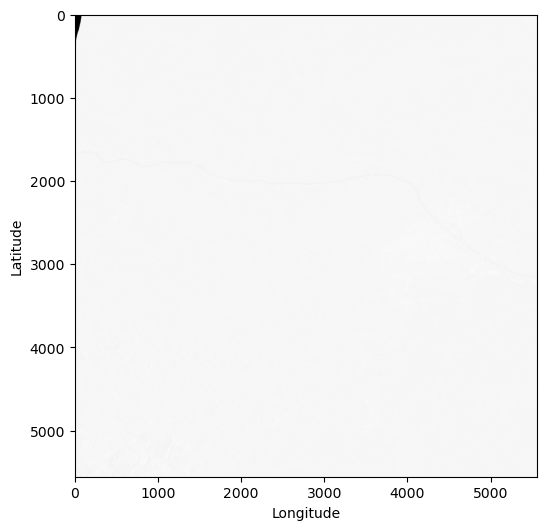

In [ ]:
vv_data = sig0_ds.VV[0,:,:]

# Plot the data
plt.figure(figsize=(10, 6))
plt.imshow(vv_data, cmap='gray')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


The data we are working with has undergone extensive processing before becoming accessible in this form.
It includes influences from the sensor, multiple corrections, transformations, and formatting steps.
Therefore, we cannot assume that the values are already scaled or cleaned.

To visualize the data effectively, we perform two important preprocessing steps.
First, we remove invalid or placeholder values that do not provide meaningful information, such as the minus nine thousand nine hundred ninety nine values.
Second, we scale the remaining values to a range between 1 and 255, corresponding to the brightness range displayable by an eight bit pixel on screen.

In [ ]:
def scale_image(arr, nodata, vmin=None, vmax=None):
    
    v_idx = arr!=nodata
    v = arr[v_idx]

    if vmin is None:
        vmin = np.min(v)
    if vmax is None:
        vmax = np.max(v)
    
    out = np.copy(arr)
    out = (out-vmin) * (254/(vmax-vmin)) + 1
    out[~v_idx] = 0

    return out.astype(np.uint8)


Test6


Before applying the scaling, we can inspect the minimum and maximum values for each time step.

In [ ]:
for i in range(3):

    print('min:',sig0_ds.VV[i,:,:].min().values,'max:',sig0_ds.VV[i,:,:].max().values)

min: -9999 max: 266
min: -9999 max: 288
min: -9999 max: 286


The data values exceed the valid range of 1 to 255 and also include a corrupted value of -9999.

This mode captures detailed surface structures such as buildings and vegetation and is less affected by volume scattering.
VH polarization transmits a vertically polarized signal and receives a horizontally polarized one, making it particularly sensitive to surface roughness and vegetation texture.

By visualizing the scaled VV and VH data for several time steps, we can observe the differences between these polarization modes.
The resulting images show how reflectivity patterns change across time and polarization.

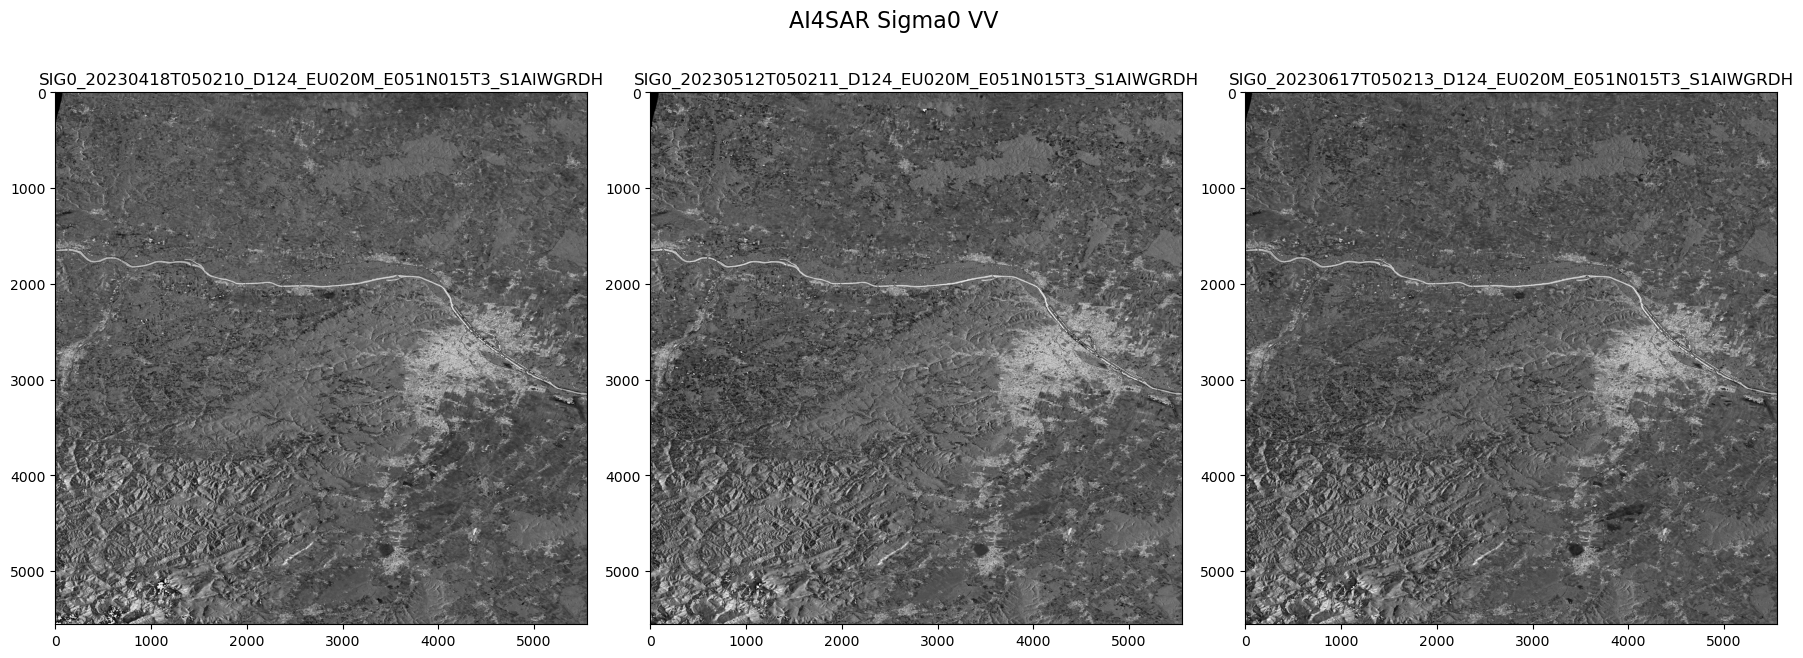

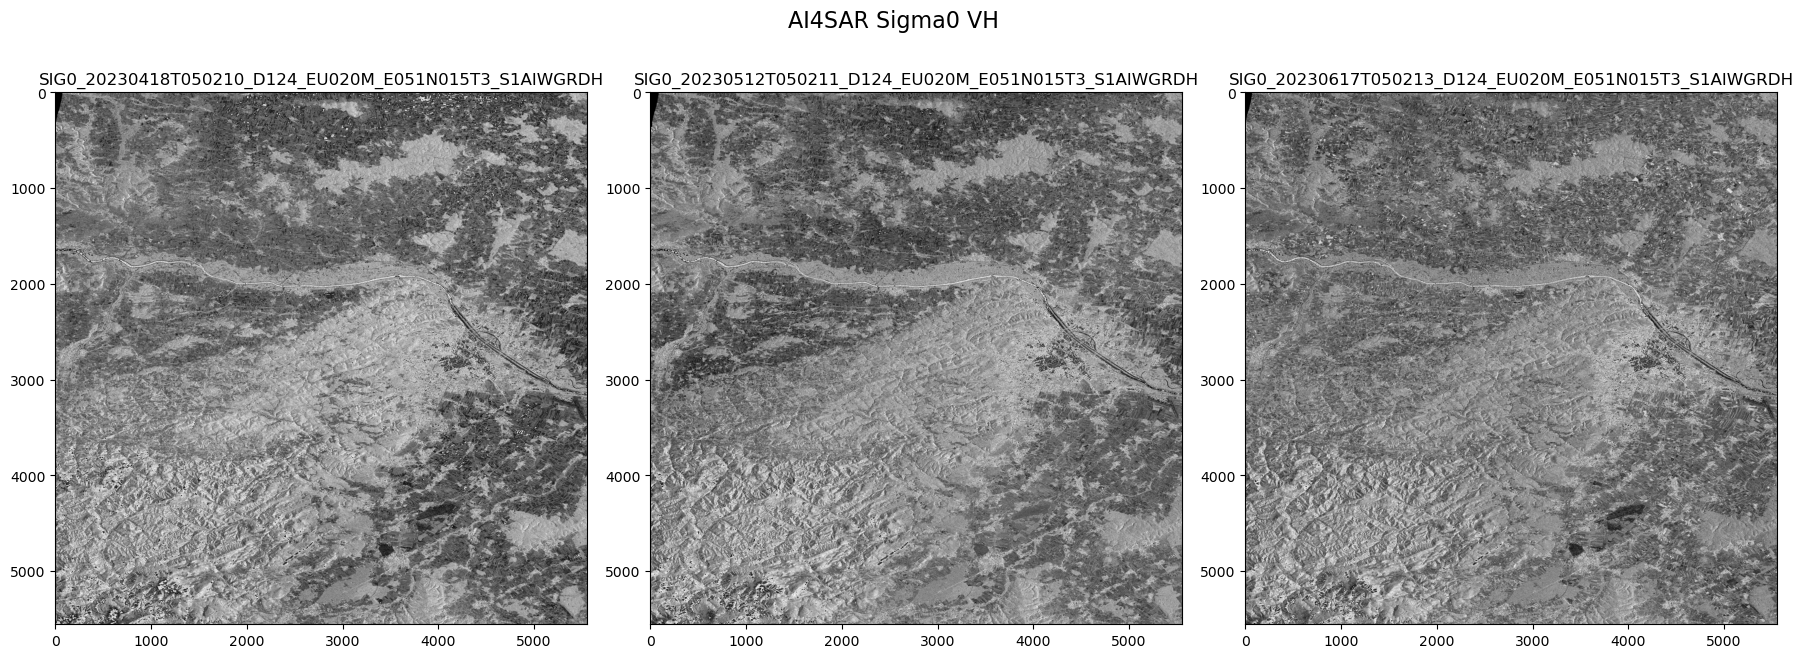

In [ ]:
fig1 = plt.figure(figsize=(18, 6))
fig1.suptitle('AI4SAR Sigma0 VV', fontsize=16, y=1.05)
nodata = -9999

for i in range(3):
    
    img = sig0_ds.VV[i,:,:].to_numpy()
    name = q_items[i].id

    gray_img = scale_image(img, nodata, vmin=-170, vmax=20)

    ax = fig1.add_subplot(1, 3, i+1)
    ax.set_title(name)
    ax.imshow(gray_img, cmap='gray')

plt.tight_layout()

fig1 = plt.figure(figsize=(18, 6))
fig1.suptitle('AI4SAR Sigma0 VH', fontsize=16, y=1.05)
nodata = -9999

for i in range(3):
    
    img = sig0_ds.VH[i,:,:].to_numpy()
    name = q_items[i].id

    gray_img = scale_image(img, nodata, vmin=-240, vmax=-100)

    ax = fig1.add_subplot(1, 3, i+1)
    ax.set_title(name)
    ax.imshow(gray_img, cmap='gray')


plt.tight_layout()

### 5. Simple Analysis

Finally, we apply a basic analytical operation to the dataset.
We compute the mean value across all available time steps for each georeferenced point.
This produces a spatial mean image for both VV and VH polarizations.

Such an operation can be useful for various applications, including long term trend analysis, noise reduction, land cover classification, soil moisture monitoring, vegetation assessment, and biomass estimation.

The resulting images display the spatial patterns of the average backscatter intensity for both polarization modes.

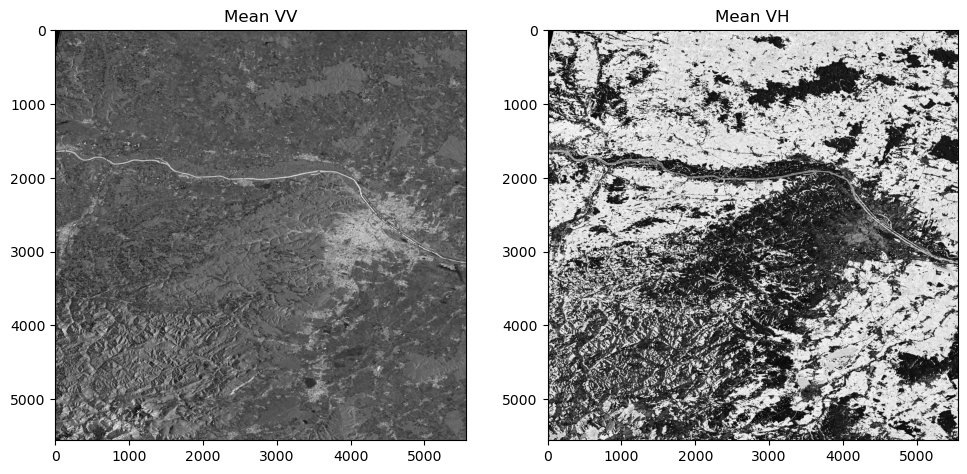

In [ ]:
fig1 = plt.figure(figsize=(18, 6))
nodata = -9999

# mean VV
vv_img  = sig0_ds.VV.mean(dim='time').to_numpy()
vv_gray_img = scale_image(vv_img, nodata, vmin=-170, vmax=20)
ax = fig1.add_subplot(1, 3, 1)
ax.set_title("Mean VV")
ax.imshow(vv_gray_img, cmap='gray')

# mean VH
vh_img = sig0_ds.VH.mean(dim='time').to_numpy()
vh_gray_img = scale_image(vh_img, nodata, vmin=-170, vmax=20)
ax = fig1.add_subplot(1, 3, 2)
ax.set_title("Mean VH")
ax.imshow(vh_gray_img, cmap='gray')